In [30]:
import torchvision.models as models



model = models.efficientnet_v2_s(
    weights=models.EfficientNet_V2_S_Weights.DEFAULT
)


In [ ]:
from torchvision.datasets import Food101
from torchvision import transforms
import torch
from torch.utils.data import DataLoader
from torchvision.models import EfficientNet_V2_S_Weights


weights = EfficientNet_V2_S_Weights.DEFAULT


transform = weights.transforms()

# Datasets
train_dataset = Food101(
    root="data",
    split="train",
    download=True,
    transform=transform
)

val_dataset = Food101(
    root="data",
    split="test",
    download=True,
    transform=transform
)

# Dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

In [ ]:
# Just do linear probing to establish baseline
# Freeze all layers except the final fully connected layer
for param in model.parameters():
    param.requires_grad = False
# Replace the final fully connected layer to match the number of classes in Food101
num_classes = 101

in_features = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(in_features, num_classes)

In [ ]:
def train(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc



In [ ]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
curr_epoch = 0



    


In [ ]:
import os

if os.path.exists("checkpoint_efficientnet_linear_probe.pt"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint_efficientnet_linear_probe.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    print("No checkpoint found, starting training from scratch")

No checkpoint found, starting training from scratch


In [ ]:
while curr_epoch < 7:
    train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_dataloader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": curr_epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc
        }, "checkpoint_efficientnet_linear_probe.pt")

    print(f"Epoch {curr_epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
    curr_epoch += 1

print("Training complete!")
print("Saving final model checkpoint")
torch.save({
    "epoch": curr_epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "best_val_acc": best_val_acc,
    "val_accs": val_accs,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "train_losses": train_losses
}, "final_checkpoint_efficientnet_linear_probe.pt")

/opt/homebrew/Caskroom/miniforge/base/envs/cv_env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/cv_env/lib/python3.14/site-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/opt/homebrew/Caskroom/miniforge/base/envs/cv_env/lib/python3.14/site-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/cv_env/lib/python3.14/site-packages/torchvision/datasets/food101.py", line 79, in __getitem__
    image = self.loader(image_file)
  File "/opt/homebrew/Caskroom/miniforge/base/envs/cv_env/lib/python3.14/site-packages/torchvision/datasets/folder.py", line 284, in default_loader
    return pil_loader(path)
  File "/opt/homebrew/Caskroom/miniforge/base/envs/cv_env/lib/python3.1

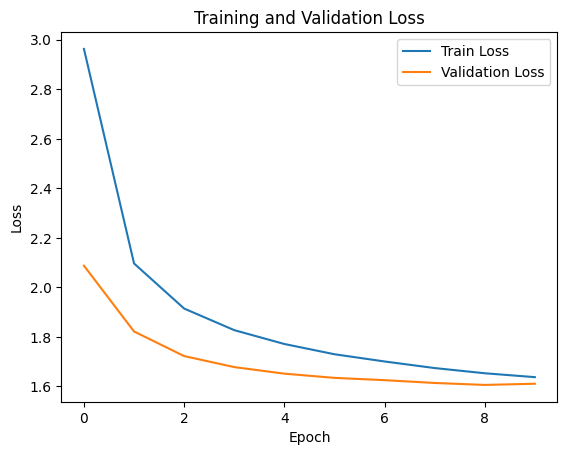

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

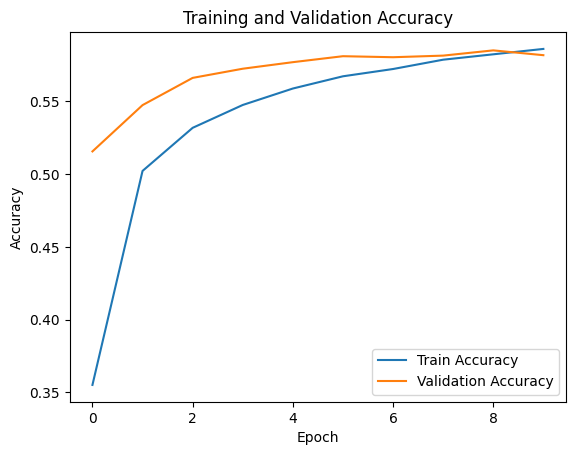

In [ ]:
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  